# 库导入

In [2]:
#  库导入
import numpy as np # 数值数学计算库
from scipy.integrate import quad # 积分计算库

import matplotlib.pyplot as plt # 绘图库
from matplotlib.ticker import FuncFormatter # 图表格式化库

from typing import Tuple # 类型提示库
import pandas as pd # 使用pandas读取信息

from gapp import dgp # GP拟合方法库

from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
import astropy.units as u
from astropy.cosmology import z_at_value


# 全局量设置

In [ ]:
# 定义全局常量
np.random.seed(202506012)
# 光速
c_light=const.c.to(u.km/u.s).value  # 定义天文学中的光速
c_mpc_yr=const.c.to(u.Mpc/u.yr) # 将光速转化为Mpc/year 的情况

# 万有引力常数
constG=const.G.to(u.Mpc**3/(u.Msun*u.s**2)).value # 是万有引力常数
constc=const.c.to(u.Mpc/u.s).value # 转换换单位为 Mpc³ / (Msun·s²)，方便天体物理和宇宙学单位下使用
 
#ACDM标准宇宙学模型=cosmo内储存了一些常量+cosmo可以计算很多宇宙学（依据其所储存的常量）量
cosmo=FlatLambdaCDM(H0=67.64,Om0=0.3087)

299792.458


# 用于计算的理论函数区（计算器）

In [3]:
# 计算ACDM模型下的红移与光度距离关系
# 输入：一维红移数组 -> 输出：二维数组[][] 红移,光度距离
def GW_calculate_ACDM(H0:float=67.64, Omega_M:float=0.3087, z=None, c:float=299792.458):
        """
        计算ACDM模型下的光度距离随红移的关系
        参数:
            H0       : 哈勃常数, km/s/Mpc
            Omega_M  : 物质密度参数
            n_points : 红移点数
            c        : 光速, km/s
        返回:
            z_vals  : 红移数组, numpy.ndarray
            dL_vals : 对应光度距离数组, numpy.ndarray, 单位Mpc
        """
        # 定义光度距离函数
        def d_L_em(z):
            def integrand(zp):
                return 1.0 / np.sqrt(Omega_M*(1+zp)**3 + (1-Omega_M))
            integral, _ = quad(integrand, 0, z)
            return (1 + z) * (c / H0) * integral

        # 向量化函数
        d_L_em_vec = np.vectorize(d_L_em)

        # 红移数组
        z_vals = np.array(z)  # 确保 z 是 numpy 数组
        dL_vals = d_L_em_vec(z_vals)
        
        ACDM_theory_data = np.column_stack((z_vals, dL_vals))
        return ACDM_theory_data 

In [4]:
# 计算RT模型下的红移与光度距离关系
# 输入：一维红移数组 -> 输出：二维数组[][] 红移,光度距离
def GW_calculate_RT(Xi:float=1.67, n:float=1.94, z=None, c:float=299792.458):
    data = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=z, c=c)
    X = data[:,0]
    Y = data[:,1]
    Y_RT = Y * (Xi + (1 - Xi)/((1 + X)**n))
    RT_theory_data = np.column_stack((X, Y_RT))
    return RT_theory_data


In [5]:
# 使用内积的方法计算误差(Fisher矩阵)
# 输入：红移值 -> 输出：信噪比值
    

# 用于画图的理论函数区

In [6]:
# 计算ACDM模型下的红移与光度距离关系（平均红移点）
# 输入：(ACDM模型参数 H0, Ωm, (计算参数) 红移最大值, 红移点数(会变成均匀的)) -> 输出：二维数组 红移值，光度距离
def GW_forplot_ACDM(H0:float=67.64, Omega_M:float=0.3087, z_max:float=5, n_points:int=200, c:float=299792.458):
    """
    计算ACDM模型下的光度距离随红移的关系
    参数:
        H0       : 哈勃常数, km/s/Mpc
        Omega_M  : 物质密度参数
        z_max    : 红移最大值
        n_points : 红移点数
        c        : 光速, km/s
    返回:
        z_vals  : 红移数组, numpy.ndarray
        dL_vals : 对应光度距离数组, numpy.ndarray, 单位Mpc
    """
    # 定义光度距离函数
    def d_L_em(z):
        def integrand(zp):
            return 1.0 / np.sqrt(Omega_M*(1+zp)**3 + (1-Omega_M))
        integral, _ = quad(integrand, 0, z)
        return (1 + z) * (c / H0) * integral

    # 向量化函数
    d_L_em_vec = np.vectorize(d_L_em)

    # 红移数组
    z_vals = np.linspace(0, z_max, n_points)
    dL_vals = d_L_em_vec(z_vals)
    
    ACDM_theory_data = np.column_stack((z_vals, dL_vals))
    return ACDM_theory_data 


In [7]:
# 计算RT模型下的红移与光度距离关系
# 输入：(RT模型参数 Xi, n, (计算参数) 红移最大值, 红移点数(会变成均匀的)) -> 输出：二维数组 红移值，光度距离
def GW_forplot_RT(Xi:float=1.67, n:float=1.94,z_max:float=5, n_points:int=200, c:float=299792.458):
    data = GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=z_max, n_points=n_points, c=c)
    X = data[:,0]
    Y = data[:,1]
    Y_RT = Y * (Xi + (1 - Xi)/((1 + X)**n))
    RT_theory_data = np.column_stack((X, Y_RT))
    return RT_theory_data


# "实验"数据处理

In [8]:
#  根据参数生成此高斯函数对应的 (x,y) 数据点 这里一共是400个点
# 输入：(均值，方差) -> 输出：对应高斯函数的点(x数组[]，y数组[]) NumPy 数组
def gaussian(mu: float, sigma2: float) -> Tuple[np.ndarray, np.ndarray]:
    sigma = np.sqrt(sigma2)
    x = np.linspace(mu - 10*sigma, mu + 10*sigma, 4000) # 在中值和方差定义的范围内生成等距x值,共400个点
    y = (1 / np.sqrt(2 * np.pi * sigma2)) * np.exp(- (x - mu)**2 / (2 * sigma2))
    return x, y

In [9]:
# 根据高斯分布随机取点 从理论d_L值到实验d_L值
# 输入：(均值，方差，采样点数) -> 输出：采样点数组sample[]  NumPy 数组
def sample_from_gaussian(mu: float, sigma2: float, n_samples: int = 1) -> np.ndarray:
    if mu == 0 and sigma2 == 0:
        return np.zeros(n_samples)
    x, y = gaussian(mu, sigma2)
    y_prob = y / y.sum()  # 将高斯函数值归一化为概率[这里是离散取点]，这里的y_prob也是一个数组
    samples = np.random.choice(x, size=n_samples, p=y_prob)  # 按概率抽样
    return samples

In [10]:
# 数据CSV文件读取并输出
# 输入：CSV文件路径 -> 输出：原始数据的NumPy数组data_array[][]
def read_csv_to_numpy(file_path: str) -> np.ndarray:
    df = pd.read_csv(file_path)  # 文件路径可以是相对路径或绝对路径
    data_array = df.to_numpy()
    return data_array # 这里返回的是一个二维Numpy数组

In [11]:
# 读取CSV文件，生成随机样本，并返回处理后的的数据数组 实验dL值和z值组合为数组
# 输入：二维数组[][3] -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def gaussianrandom_to_newnumpy(data:np.ndarray) -> np.ndarray:
    samples_list = []

    # 忽略第一列 z值保留
    mu_values = data[:, 1]      # 第二列    
    sigma2_values = data[:, 2]**2  # 第三列    
    for mu, sigma2 in zip(mu_values, sigma2_values):
        sample = sample_from_gaussian(mu, sigma2,1)
        samples_list.append(sample[0])  # sample 是数组，取第0个元素
    samples_array = np.array(samples_list)

    new_data = np.column_stack((data[:, 0], samples_array, data[:, 2]))
    return new_data

In [12]:
# 根据文件数据读取红移分布 根据ACDM生成样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def ACDM_csv_to_newnumpy(file_path: str) -> np.ndarray:
    data = read_csv_to_numpy(file_path)

    # 忽略第一列
    z_values = data[:, 0]      # 第一列
    data2 = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=z_values, c=299792.458)
    mu_values = data2[:,1]      # 第二列    
    fixed_data = np.column_stack((data[:, 0], mu_values, data[:, 2]))
    receive = gaussianrandom_to_newnumpy(fixed_data)
    return receive

In [13]:
# 读取根据文件数据，读取红移分布 根据ACDM生成样本，并返回处理后的的数据数组
# 输入：CSV文件路径 -> 输出：高斯撒点处理后的NumPy数组data_array[][]
def GT_csv_to_newnumpy(file_path: str) -> np.ndarray:
    data = read_csv_to_numpy(file_path)

    # 忽略第一列
    z_values = data[:, 0]      # 第一列
    data2 = GW_calculate_RT(Xi=1.67, n=1.94, z=z_values, c=299792.458)
    mu_values = data2[:,1]     # 第二列
    fixed_data = np.column_stack((data[:, 0], mu_values, data[:, 2]))
    receive = gaussianrandom_to_newnumpy(fixed_data)
    return receive

In [ ]:
# 使用GaPP方法处理二维数组
# 输入：(二维数组data_array[][3], 以及模型参数) -> 输出：GaPP处理后的二维数组GaPP_data[][]
def gapp_solve(data:np.ndarray, xmin=0.0, xmax=10.0, nstar=200, initheta=[2.0,2.0]):
    """
    对输入数据 X,Y,Sigma 执行 Gaussian Process 重构
    
    返回：
    - Xstar: 重构函数对应横坐标
    - rec: 重构函数
    - drec: 一阶导数
    - d2rec: 二阶导数
    - d3rec: 三阶导数
    """
    X = data[:,0]
    Y = data[:,1]
    Sigma = data[:,2]

    # initialization of the Gaussian Process
    g = dgp.DGaussianProcess(X, Y, Sigma, cXstar=(xmin, xmax, nstar))

    # training of the hyperparameters and reconstruction of the function
    (rec, theta) = g.gp(theta=initheta)
    # 注意rec是重构函数的二维数组 横坐标[:,0] , 纵坐标[:,1] , 误差值[:,2]

    # reconstruction of the first, second and third derivatives.
    # theta is fixed to the previously determined value.
    (drec, theta) = g.dgp(thetatrain='False')
    (d2rec, theta) = g.d2gp()
    (d3rec, theta) = g.d3gp()
    
    # 用字典返回多个值
    result = {
        "X": X,
        "Y": Y,
        "Sigma": Sigma,
        "rec": rec,
        "drec": drec,
        "d2rec": d2rec,
        "d3rec": d3rec,
        "theta": theta
    }
    return result

# 画图区

In [15]:
# 绘制二维数组对应的理论曲线图（绘制曲线时使用）
# 输入：(二维数组data_array[..][2], 图例标签，) -> 输出：无（一个待打印的图）
def plot_line(data:np.ndarray, label:str,linecolor:str='red'):
    X = data[:,0]
    Y = data[:,1]
    plt.plot(X, Y, label=label, color=linecolor, linewidth=1.2)

In [16]:
# 绘制二维数组带error bar的散点图
# 输入：(二维数组data_array[..][3], 图例标签，点线样式，误差条颜色) -> 输出：无（一个待打印的图）
def plot_spot_with_error(data: np.ndarray, label: str = "Data", fmt: str='_', color:str='red'):
    """
    绘制带误差条的折线图（不创建新图、不调用 plt.show()，方便多次叠加）
    参数:
    - data: 二维 NumPy 数组, 每行 [x, y, error]
    - label: 图例标签
    - fmt: 点线样式
    - ecolor: 误差条颜色
    """
    x = data[:, 0]
    y = data[:, 1]
    yerr = data[:, 2]

    plt.errorbar(x, y, yerr=yerr, fmt=fmt, ecolor=color, elinewidth=0.5 ,color=color,label=label)

In [17]:
# 绘制GaPP处理后的二维数据的图
# 输入：数据字典 -> 输出：无（一个待打印的图）
def plot_gapp(result_dict: dict, Label: str = "Reconstruction from GP"):
    X = result_dict["X"]
    Y = result_dict["Y"]
    Sigma = result_dict["Sigma"]
    rec = result_dict["rec"]
    drec = result_dict["drec"]
    d2rec = result_dict["d2rec"]
    d3rec = result_dict["d3rec"]
    
    # plt.xlim(0, 0.1)
    plt.fill_between(rec[:, 0], rec[:, 1] - 2*rec[:, 2], rec[:, 1] + 2*rec[:, 2], facecolor='lightblue' ) 
    plt.fill_between(rec[:, 0], rec[:, 1] - rec[:, 2], rec[:, 1] + rec[:, 2], facecolor='blue',  label=Label)
    # plt.plot(rec[:, 0], rec[:, 1],color="red")  # 这个是重构的曲线的值(GP重构出的函数)
    # plt.errorbar(X, Y, Sigma, color='red', fmt='_')
    

In [48]:
# 控制生成figure的结构
def plot_show(
        xlimDOWN:float=0,xlimUP:float=0.12, 
        ylimDOWN=None, ylimUP=None,
        xlabel:str="Redshift z", ylabel:str="", 
        title:str="", zoom:float=1000.0 
):
    # plt.figure(figsize=(8,5))
    plt.xlim(xlimDOWN, xlimUP)
    
    # 设置纵轴上下限
    if ylimDOWN is not None and ylimUP is not None:
        plt.ylim(ylimDOWN, ylimUP)
    elif ylimDOWN is not None:
        plt.ylim(bottom=ylimDOWN)
    elif ylimUP is not None:
        plt.ylim(top=ylimUP)
        
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/zoom:.1f}'))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show() 

# 运行调试区

  NIT   NF   F                       GTG
    0    1  2.268492391917254E+03   5.19556973E+07
tnc: fscale = 0.000136768
    1    7  2.187872290868175E+03   1.28328907E+05
tnc: stepmx = 1000
    2   11  7.893201293608428E+02   1.06180200E+07
    3   17  1.772324483527475E+02   1.25506587E+05
tnc: fscale = 0.00279236
    4   19  1.756890144599412E+02   1.50067126E+02
    5   24  1.340981133487400E+02   7.70333207E+05
    6   27  9.930011505426677E+01   2.82875076E+04
    7   30  8.025640122513269E+01   7.10134689E-01
tnc: fscale = 1.1729
    8   41  8.007189756548647E+01   2.38556635E-02
    9   43  8.007154922946862E+01   3.28086312E-01
   10   46  7.746315392034786E+01   3.68985197E+00
   11   51  7.739547349773261E+01   3.01188391E+00
   12   53  7.738193179330420E+01   9.02329075E-02
   13   55  7.737895106361546E+01   5.05935438E-01
   14   57  7.736942172519426E+01   5.55721572E-02
   15   59  7.736885565876894E+01   5.58995598E-06
tnc: fscale = 418.754
   16   61  7.736885560500474E


Optimized hyperparameters:
theta = [1.17662873e+03 3.88399597e-01]


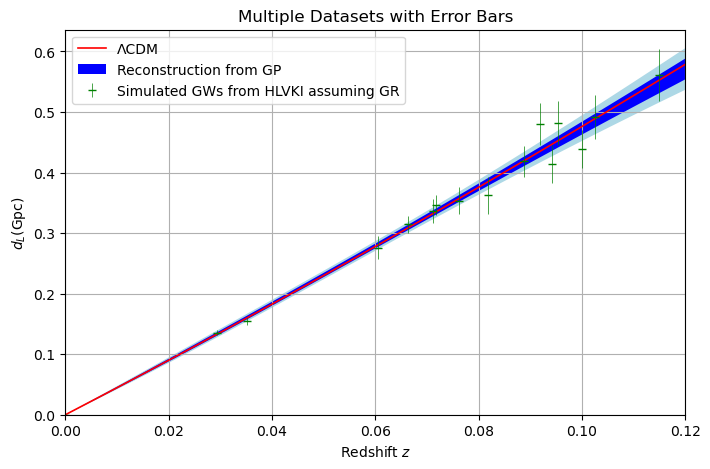

  NIT   NF   F                       GTG
    0    1  2.537471412377643E+03   6.63648314E+07
tnc: fscale = 0.000121061
    1    7  2.441639605027501E+03   3.67703689E+05
tnc: stepmx = 1000
    2   11  6.390712772326634E+02   1.26041611E+07
    3   15  1.914179035467273E+02   1.49439179E+05
tnc: fscale = 0.00255877
    4   17  1.899344298891198E+02   3.93154678E+01
tnc: fscale = 0.0565262
    5   19  1.897355442624899E+02   1.55336336E+04
    6   22  9.189116808916633E+01   5.97945006E+02
    7   25  7.965470184594096E+01   3.73543408E+02
    8   28  7.816202032186635E+01   2.75444325E+01
    9   30  7.803521006978582E+01   1.96674143E-02
tnc: fscale = 7.05994
   10   32  7.803511478197865E+01   2.09500233E-07
tnc: fscale = 1384.68
tnc: |fn-fn-1] = 7.42955e-09 -> convergence
   11   34  7.803511477454910E+01   7.14587756E-07
tnc: Converged (|f_n-f_(n-1)| ~= 0)



Optimized hyperparameters:
theta = [1.08268066e+03 2.96685342e-01]


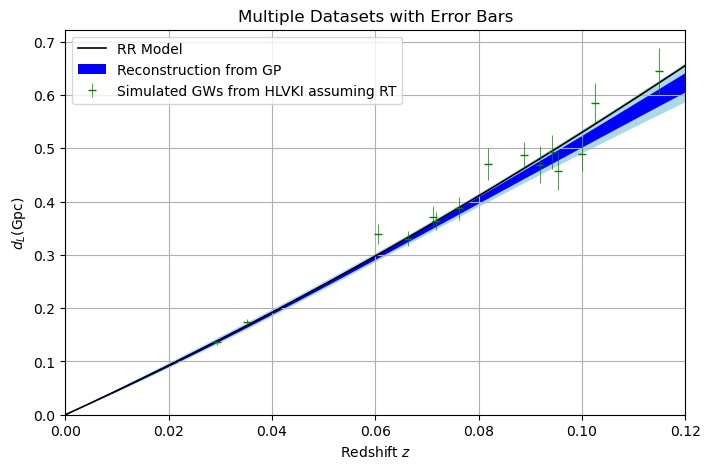

  NIT   NF   F                       GTG
    0    1  4.168978771805391E+04   1.52877535E+10
tnc: fscale = 8.00408e-06
    1    4  3.738039311112451E+04   1.46439711E+08
    2   12  2.805288578611953E+04   1.87482003E+09
    3   16  9.125204267665580E+03   8.69670846E+09
    4   19  5.349745882928641E+03   2.28565658E+06
tnc: fscale = 0.000617509
    5   21  5.334459874676412E+03   9.06604991E+04
tnc: stepmx = 1000
    6   24  3.180325926724599E+03   6.92215670E+05
    7   28  2.700342285260692E+03   5.38883536E+06
    8   31  2.633474847640183E+03   2.30932221E+05
    9   35  2.412027729850684E+03   2.19543728E+05
   10   38  2.380179958645814E+03   3.02869509E+04
   11   42  2.303372725115727E+03   5.49593554E+03
tnc: fscale = 0.0133553
   12   47  2.301540089051273E+03   9.78549864E+00
tnc: fscale = 0.315164
   13   49  2.301537532137147E+03   1.58328311E-02
   14   52  2.283549030259039E+03   1.60466786E+00
   15   56  2.280612414631524E+03   2.63253106E+00
   16   58  2.28049776151


Optimized hyperparameters:
theta = [3.62250977e+03 9.43748045e-01]


tnc: |fn-fn-1] = 1.27654e-09 -> convergence
   20   66  2.280490104746534E+03   3.74417958E-11
tnc: Converged (|f_n-f_(n-1)| ~= 0)


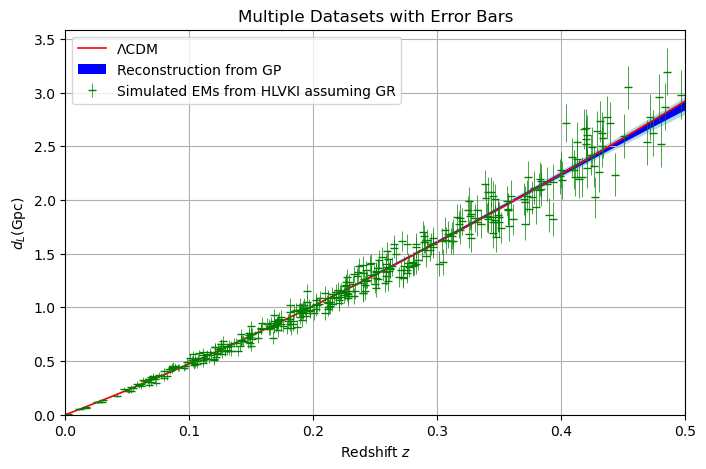

In [ ]:
plt.figure(figsize=(8,5))  # 先创建 figure
plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.12, n_points=200), label='ΛCDM', linecolor='red')
plot_gapp(gapp_solve(ACDM_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=200, initheta=[2.0,0.01]), Label='Reconstruction from GP')
plot_spot_with_error(ACDM_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming GR', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5))  # 先创建 figure
plot_line(GW_forplot_RT(Xi=1.67, n=1.94, z_max=0.12, n_points=200), label='RR Model', linecolor='black')
plot_gapp(gapp_solve(GT_csv_to_newnumpy('Data/GR_GW.csv'), xmin=0, xmax=0.12, nstar=200, initheta=[2.0,0.01]), Label='Reconstruction from GP')
plot_spot_with_error(GT_csv_to_newnumpy('Data/GR_GW.csv'), label='Simulated GWs from HLVKI assuming RT', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.12,ylimDOWN=0,xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)

plt.figure(figsize=(8,5))  # 先创建 figure
plot_line(GW_forplot_ACDM(H0=67.64, Omega_M=0.3087, z_max=0.5, n_points=200), label='ΛCDM', linecolor='red')
plot_gapp(gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.5, nstar=200, initheta=[2.0,0.01]), Label='Reconstruction from GP')
plot_spot_with_error(ACDM_csv_to_newnumpy('Data/outputEM.csv'), label='Simulated EMs from HLVKI assuming GR', fmt='_', color='green')
plot_show(xlimDOWN=0,xlimUP=0.5,ylimDOWN=0, xlabel="Redshift $z$", ylabel="$d_L$(Gpc)", title="Multiple Datasets with Error Bars", zoom=1000.0)



# 二级计算计算

## 计算理论比值

In [ ]:
def Dz_GR(z_max,n_point):
    x = np.linspace(0,z_max,n_point)
    y = np.full_like(x, 1.0)
    Dz = np.column_stack((x,y))
    return Dz
    

In [56]:
def Dz_RT(z_max,n_point):
    x = np.linspace(0,z_max,n_point) 
    d_EM = GW_calculate_ACDM(H0=67.64, Omega_M=0.3087, z=x, c=c_light)
    d_GW = GW_calculate_RT(Xi=1.67, n=1.94, z=x, c=c_light)

    # 处理 0/0 的情况
    y = np.zeros_like(x)
    y[1:] = d_GW[1:,1] / d_EM[1:,1]
    y[0] = 1.0  # 理论上在z=0时应相等

    Dz = np.column_stack((x,y))
    return Dz

# Dz = Dz_RT(1.2,100)
# print(Dz[:10])

## 计算实验重构比值

In [58]:
def Dz_gapp_GR():
    GWz = gapp_solve(ACDM_csv_to_newnumpy('Data/GR_GW.csv'),xmin=0, xmax=0.5, nstar=200, initheta=[2.0,0.01])
    EMz = gapp_solve(ACDM_csv_to_newnumpy('Data/outputEM.csv'), xmin=0, xmax=0.5, nstar=200, initheta=[2.0,0.01])

    recGW = GWz["rec"]
    recEM = EMz["rec"]

    x1, y1, sigma1 = recGW[:,0], recGW[:,1], recGW[:,2]
    x2, y2, sigma2 = recEM[:,0], recEM[:,1], recEM[:,2]

    Dz = y1 / y2

    # 误差传播
    sigma_ratio = np.abs(Dz) * np.sqrt(
        (sigma1/y1)**2 + (sigma2/y2)**2
    )

    data = np.column_stack((x1,Dz,sigma_ratio))

    dict = gapp_solve(data, xmin=0, xmax=0.5, nstar=200, initheta=[2.0,0.01])
    return dict


  NIT   NF   F                       GTG
    0    1  2.213098178866514E+03   5.14338127E+07
tnc: fscale = 0.000137449
    1    7  2.134315044542857E+03   1.79274818E+05
tnc: stepmx = 1000
    2   11  6.617093520731742E+02   1.02306442E+07
    3   15  1.715619192164777E+02   3.60194145E+05
    4   17  1.671980993714159E+02   1.87064561E+03
tnc: fscale = 0.021907
    5   19  1.671695073466086E+02   4.99099669E+01
    6   22  9.001763281280782E+01   4.74821786E+00
tnc: fscale = 0.44202
    7   26  9.001267338791348E+01   3.86917909E-01
    8   29  8.410583860184313E+01   1.91264461E+04
tnc: fscale = 0.00715915
    9   32  8.067875076367338E+01   1.91588520E+02
   10   34  8.049917941963454E+01   5.22402004E+00
tnc: fscale = 0.433167
   11   36  8.049502682040634E+01   1.09039907E-03
tnc: fscale = 24.1725
   12   38  8.049502456889789E+01   5.08303987E-04
   13   41  7.942317057590751E+01   5.02710864E-02
   14   43  7.941931497003088E+01   1.17053315E-02
   15   45  7.941899370985729E+01 


Optimized hyperparameters:
theta = [1.03963388e+03 3.76591768e-01]


  NIT   NF   F                       GTG
    0    1  4.170914866393388E+04   1.51713006E+10
tnc: fscale = 8.03468e-06
    1    4  3.736463593029854E+04   1.60164533E+08
    2   11  2.816402721942362E+04   1.40745556E+09
    3   13  2.582657548660798E+04   1.56207330E+10
    4   16  5.908704719230947E+03   9.44706701E+07
tnc: stepmx = 1000
    5   19  3.107902994929459E+03   2.12999253E+06
tnc: fscale = 0.000677793
    6   24  3.001830785489109E+03   1.28232751E+03
tnc: fscale = 0.0148738
    7   26  3.001420103610918E+03   1.18066262E+04
    8   29  2.371905359451289E+03   1.02709464E+05
    9   32  2.328332791366215E+03   8.68139947E+03
   10   35  2.295697166058117E+03   1.59070663E+03
   11   41  2.284338094884741E+03   3.89323262E+01
   12   43  2.284256901694865E+03   3.82560016E-01
tnc: fscale = 1.60045
   13   45  2.284256138833473E+03   3.65734576E-05
tnc: fscale = 70.8454
   14   47  2.284256134104173E+03   1.99326899E-03
   15   50  2.282358198316499E+03   3.59633514E+00
tnc:


Optimized hyperparameters:
theta = [5.07414319e+03 1.18841818e+00]


tnc: |fn-fn-1] = 2.96899e-09 -> convergence
   23   70  2.281766841876560E+03   6.60910470E-08
tnc: Converged (|f_n-f_(n-1)| ~= 0)
  NIT   NF   F                       GTG
    0    1 -1.208318756601884E+02   2.01942223E+08
tnc: fscale = 6.96721e-05
    1    5 -1.587642483992355E+02   9.27300435E+06
    2    9 -1.676525512337946E+02   1.10453238E+04
tnc: fscale = 0.00939687
    3   11 -1.676601717442956E+02   1.14669093E+01
    4   17 -1.701698220438920E+02   4.36368475E+05
    5   21 -1.703199019226068E+02   4.77169427E+05
    6   23 -1.705483919233692E+02   1.42661642E+03
    7   25 -1.705492775025157E+02   1.61649132E+01
tnc: fscale = 0.245952
    8   27 -1.705492848195596E+02   2.67769317E-03
tnc: fscale = 6.53207
    9   29 -1.705492895905699E+02   9.70832156E+00
tnc: fscale = 0.317256
   10   31 -1.705492939909438E+02   2.29108223E-03
tnc: fscale = 7.07732
   11   33 -1.705492973723045E+02   6.97124821E+00
   12   35 -1.705493468311802E+02   5.89606583E-06
tnc: fscale = 406.479



Optimized hyperparameters:
theta = [0.97093173 0.01489804]


tnc: |fn-fn-1] = 1.82579e-12 -> convergence
   13   37 -1.705493468311820E+02   7.04362102E-09
tnc: Converged (|f_n-f_(n-1)| ~= 0)


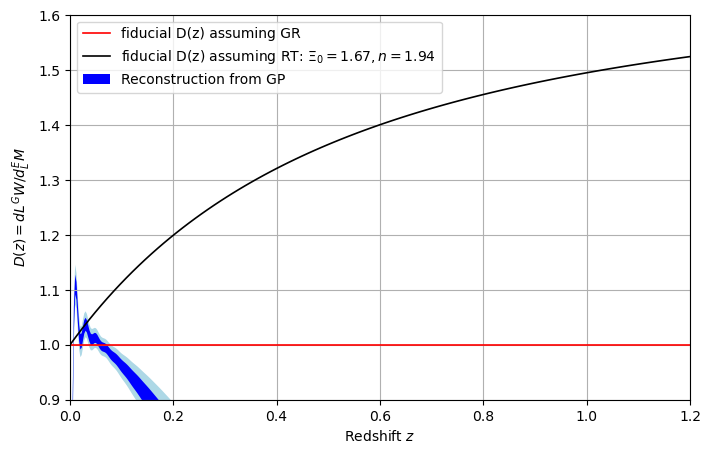

In [60]:
plt.figure(figsize=(8,5))  # 先创建 figure
plot_line(Dz_GR(1.2,100), label='fiducial D(z) assuming GR', linecolor='red')
plot_line(Dz_RT(1.2,100), label='fiducial D(z) assuming RT: $\Xi_0 =1.67, n=1.94$', linecolor='black')
plot_gapp(Dz_gapp_GR(), Label='Reconstruction from GP')
plot_show(xlimDOWN=0,xlimUP=1.2,ylimDOWN=0.9, xlabel="Redshift $z$", ylabel="$D(z)= dL^GW / d_L^EM$",zoom=1)
